###### w

## Image Classification 
## What is this animal ? feature

### Data Preparing (unzip + spliting + translation)

In [2]:
# raw image folder
raw_dir = "C:\\Users\\Waseem Al-mahainy\\Desktop\\UnI\\5th Year\\1st sem\\Jr\\Jr project\\Image classification what is this feature\\data\\raw-img" 

# translation from italian to english
categories = {
    "cane": "dog",
    "cavallo": "horse",
    "elefante": "elephant",
    "farfalla": "butterfly",
    "gallina": "chicken",
    "gatto": "cat",
    "mucca": "cow",
    "pecora": "sheep",
    "scoiattolo": "squirrel",
    "ragno": "spider",
}

# class names in english
animals = ["dog", "horse", "elephant", "butterfly", "chicken",
           "cat", "cow", "sheep", "squirrel", "spider"]

print("Raw dir:", raw_dir)
print("Italian folders found:", os.listdir(raw_dir))
print("English labels:", animals)

Raw dir: C:\Users\Waseem Al-mahainy\Desktop\UnI\5th Year\1st sem\Jr\Jr project\Image classification what is this feature\data\raw-img
Italian folders found: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']
English labels: ['dog', 'horse', 'elephant', 'butterfly', 'chicken', 'cat', 'cow', 'sheep', 'squirrel', 'spider']


In [3]:
split_base = "animals10_split"

splits = ["train", "test"]

for split in splits:
    for eng_label in animals:
        dst_dir = os.path.join(split_base, split, eng_label)
        os.makedirs(dst_dir, exist_ok=True)

print("Created structure under:", split_base)

Created structure under: animals10_split


In [4]:
## helper fun to get the images 
def get_all_images(folder):
    exts = ["*.jpg", "*.JPG", "*.jpeg", "*.JPEG", "*.png", "*.PNG"]
    files = []
    for ext in exts:
        files.extend(glob.glob(os.path.join(folder, ext)))
    return [f for f in files if os.path.isfile(f)]

In [5]:
for it_label, eng_label in categories.items():
    src_class_dir = os.path.join(raw_dir, it_label)
    images = get_all_images(src_class_dir)
    images = sorted(images)

    print(f"{it_label} ({eng_label}) - total images: {len(images)}")

    if len(images) == 0:
        continue

    train_imgs, test_imgs = train_test_split(
        images, test_size=0.2, random_state=42
    )

    # Copy train images
    for src in train_imgs:
        dst = os.path.join(split_base, "train", eng_label, os.path.basename(src))
        shutil.copy2(src, dst)

    # Copy test images
    for src in test_imgs:
        dst = os.path.join(split_base, "test", eng_label, os.path.basename(src))
        shutil.copy2(src, dst)

print("Done splitting into train/test.")

cane (dog) - total images: 9726
cavallo (horse) - total images: 5246
elefante (elephant) - total images: 2892
farfalla (butterfly) - total images: 4224
gallina (chicken) - total images: 6196
gatto (cat) - total images: 3336
mucca (cow) - total images: 3732
pecora (sheep) - total images: 3640
scoiattolo (squirrel) - total images: 3724
ragno (spider) - total images: 9642
Done splitting into train/test.


In [6]:
def count_images_in(split):
    total = 0
    for eng_label in animals:
        folder = os.path.join(split_base, split, eng_label)
        n = len(os.listdir(folder))
        print(f"{split} - {eng_label}: {n}")
        total += n
    print(f"Total {split} images:", total)

print("=== TRAIN ===")
count_images_in("train")
print("=== TEST ===")
count_images_in("test")


=== TRAIN ===
train - dog: 4687
train - horse: 2506
train - elephant: 1388
train - butterfly: 2043
train - chicken: 2977
train - cat: 1602
train - cow: 1791
train - sheep: 1743
train - squirrel: 1796
train - spider: 4616
Total train images: 25149
=== TEST ===
test - dog: 1770
test - horse: 933
test - elephant: 521
test - butterfly: 776
test - chicken: 1119
test - cat: 602
test - cow: 672
test - sheep: 651
test - squirrel: 679
test - spider: 1724
Total test images: 9447


In [7]:
from pathlib import Path
from PIL import Image, UnidentifiedImageError

bad_files = []

for img_path in Path(raw_dir).rglob("*.*"):
    try:
        img = Image.open(img_path)
        img.verify()  # verify is enough; no need to load fully
    except (UnidentifiedImageError, OSError):
        print("Corrupted image:", img_path)
        bad_files.append(str(img_path))

print("Total corrupted images:", len(bad_files))


Total corrupted images: 0


### import libraries

In [6]:
from sklearn.model_selection import train_test_split
import os
import shutil
import glob
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from keras.layers import Dense, Flatten ,Dropout, Conv2D, MaxPooling2D, BatchNormalization
from keras.models import Sequential
from keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import Callback, EarlyStopping,ModelCheckpoint, ReduceLROnPlateau
from keras.optimizers import Adam

### gpu check + grow memory

In [16]:
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(gpus))
if gpus:
    for i, gpu in enumerate(gpus):
        details = tf.config.experimental.get_device_details(gpu)
        print(f"GPU {i} Name: {details.get('device_name', 'Unknown')}")
else:
    print("No GPU found.")

Num GPUs Available:  1
GPU 0 Name: NVIDIA GeForce RTX 3060 Laptop GPU


In [17]:
gpus = tf.config.list_physical_devices('GPU')
print("GPUs:", gpus)
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth enabled.")
    except Exception as e:
        print("Could not set memory growth:", e)


GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Memory growth enabled.


### Data Augmentation and building the models

#### 1st experiment

##### preprocessing (data augmentation + loading the images)

In [15]:
img_size = (224, 224)
batch_size =64

base_dir  = "C:\\Users\\Waseem Al-mahainy\\Desktop\\UnI\\5th Year\\1st sem\\Jr\\Jr project\\Image classification what is this feature\\animals10_split"
train_dir = os.path.join(base_dir, "train")
test_dir  = os.path.join(base_dir, "test")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest",
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_ds = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True,
    seed=42,
)

test_ds = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False,
)

class_names = list(train_ds.class_indices.keys())
num_classes = len(class_names)
print("Classes:", class_names)
print("Num classes:", num_classes)

Found 25149 images belonging to 10 classes.
Found 9447 images belonging to 10 classes.
Classes: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']
Num classes: 10


##### network structure and Training the model experiments

In [19]:
model1 = Sequential([
    
    Conv2D(16, (3,3), activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Flatten(),
    Dense(10, activation='softmax')
])

In [20]:
model1.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [21]:
history1 = model1.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds,
)

Epoch 1/10
393/393 [==============================] - 185s 468ms/step - loss: 3.0209 - accuracy: 0.3767 - val_loss: 3.4183 - val_accuracy: 0.2767
Epoch 2/10
393/393 [==============================] - 181s 460ms/step - loss: 2.2209 - accuracy: 0.4915 - val_loss: 2.6065 - val_accuracy: 0.4502
Epoch 3/10
393/393 [==============================] - 179s 455ms/step - loss: 1.6314 - accuracy: 0.5633 - val_loss: 1.6245 - val_accuracy: 0.5824
Epoch 4/10
393/393 [==============================] - 184s 467ms/step - loss: 1.3272 - accuracy: 0.6069 - val_loss: 1.2413 - val_accuracy: 0.6343
Epoch 5/10
393/393 [==============================] - 184s 469ms/step - loss: 1.1369 - accuracy: 0.6487 - val_loss: 1.1722 - val_accuracy: 0.6359
Epoch 6/10
393/393 [==============================] - 181s 461ms/step - loss: 1.0080 - accuracy: 0.6735 - val_loss: 1.0998 - val_accuracy: 0.6551
Epoch 7/10
393/393 [==============================] - 177s 449ms/step - loss: 0.9173 - accuracy: 0.6964 - val_loss: 0.9265 -

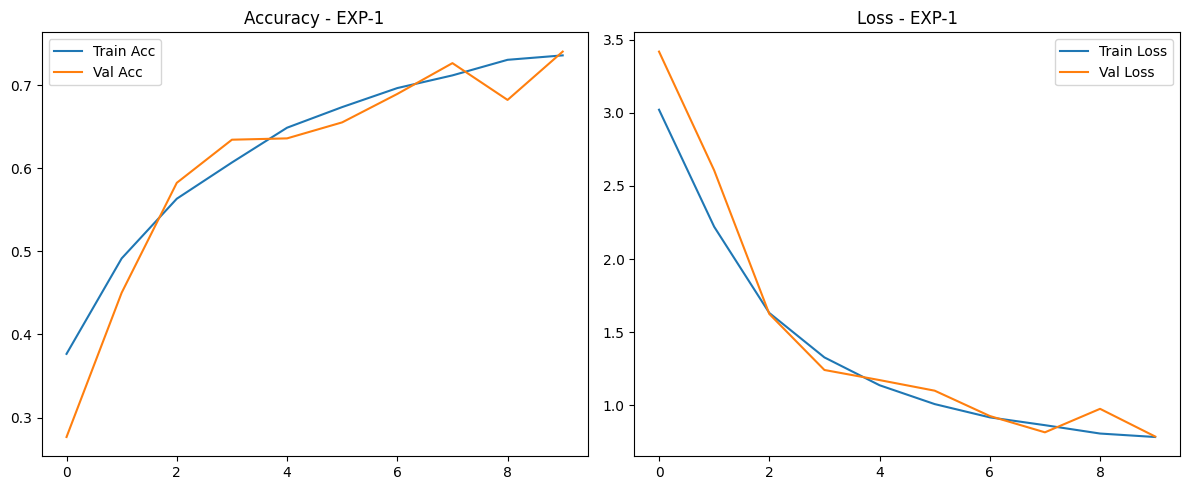

In [22]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history1.history['accuracy'], label='Train Acc')
plt.plot(history1.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy - EXP-1')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history1.history['loss'], label='Train Loss')
plt.plot(history1.history['val_loss'], label='Val Loss')
plt.title('Loss - EXP-1')
plt.legend()

plt.tight_layout()
plt.show()

#### 2nd experiment (increase 1 layer , increase batch size to 64)

##### preprocessing (data augmentation + loading the images)

In [23]:
img_size = (224, 224)
batch_size =64

base_dir  = "C:\\Users\\Waseem Al-mahainy\\Desktop\\UnI\\5th Year\\1st sem\\Jr\\Jr project\\Image classification what is this feature\\animals10_split"
train_dir = os.path.join(base_dir, "train")
test_dir  = os.path.join(base_dir, "test")

train_datagen2 = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest",
)

test_datagen2 = ImageDataGenerator(
    rescale=1./255
)

train_ds2 = train_datagen2.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True,
    seed=42,
)

test_ds2 = test_datagen2.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False,
)

Found 25149 images belonging to 10 classes.
Found 9447 images belonging to 10 classes.


##### network structure and Training the model experiments

In [24]:
model2 = Sequential([
    
    Conv2D(16, (3,3), activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    Flatten(),
    Dense(10, activation='softmax')
])

In [25]:
model2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [26]:
history2 = model2.fit(
    train_ds2,
    epochs=10,
    validation_data=test_ds2,
    batch_size=64
)

Epoch 1/10
393/393 [==============================] - 271s 686ms/step - loss: 1.5650 - accuracy: 0.4857 - val_loss: 2.9653 - val_accuracy: 0.2077
Epoch 2/10
393/393 [==============================] - 174s 442ms/step - loss: 1.0931 - accuracy: 0.6267 - val_loss: 1.0048 - val_accuracy: 0.6618
Epoch 3/10
393/393 [==============================] - 178s 453ms/step - loss: 0.9391 - accuracy: 0.6859 - val_loss: 0.9583 - val_accuracy: 0.6732
Epoch 4/10
393/393 [==============================] - 175s 444ms/step - loss: 0.8467 - accuracy: 0.7146 - val_loss: 1.8005 - val_accuracy: 0.5241
Epoch 5/10
393/393 [==============================] - 177s 451ms/step - loss: 0.7695 - accuracy: 0.7433 - val_loss: 0.7392 - val_accuracy: 0.7649
Epoch 6/10
393/393 [==============================] - 179s 455ms/step - loss: 0.7166 - accuracy: 0.7626 - val_loss: 0.8071 - val_accuracy: 0.7287
Epoch 7/10
393/393 [==============================] - 174s 443ms/step - loss: 0.6705 - accuracy: 0.7782 - val_loss: 0.7629 -

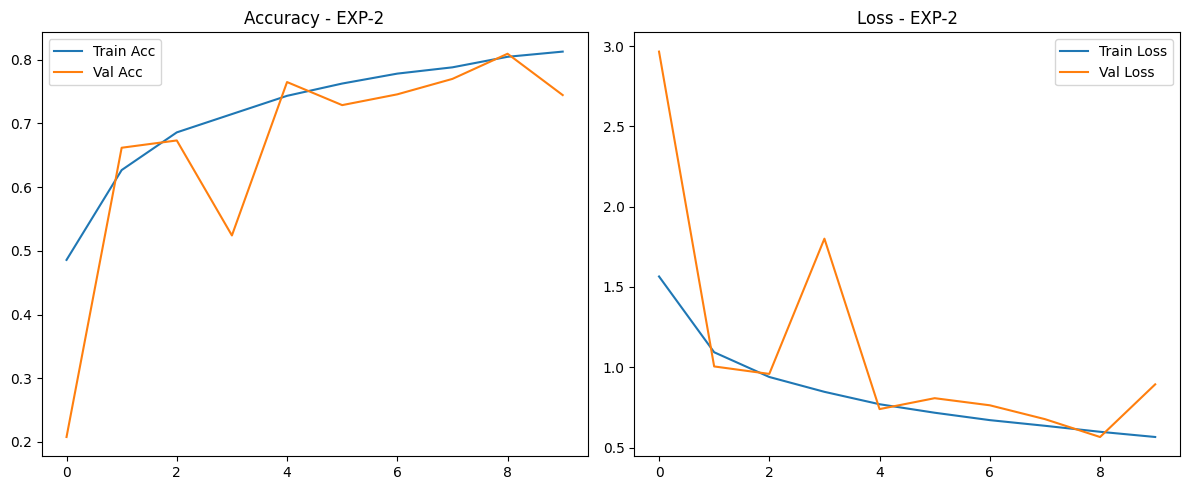

In [27]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history2.history['accuracy'], label='Train Acc')
plt.plot(history2.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy - EXP-2')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Val Loss')
plt.title('Loss - EXP-2')
plt.legend()

plt.tight_layout()
plt.show()

#### 3rd experiment (increase number of epochs , decrease batch size to 32 , add drop out ) + augmentation still the same like exp-2

In [28]:
img_size = (224, 224)
batch_size =64

base_dir  = "C:\\Users\\Waseem Al-mahainy\\Desktop\\UnI\\5th Year\\1st sem\\Jr\\Jr project\\Image classification what is this feature\\animals10_split"
train_dir = os.path.join(base_dir, "train")
test_dir  = os.path.join(base_dir, "test")

train_datagen3 = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest",
)

test_datagen3 = ImageDataGenerator(
    rescale=1./255
)

train_ds3 = train_datagen3.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True,
    seed=42,
)

test_ds3 = test_datagen3.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False,
)

Found 25149 images belonging to 10 classes.
Found 9447 images belonging to 10 classes.


In [29]:
model3 = Sequential([
    
    Conv2D(16, (3,3), activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Dropout(0.3),
    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    Flatten(),
    Dense(10, activation='softmax')
])

In [30]:
model3.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [32]:
history3 = model3.fit(
    train_ds2,
    epochs=30,
    validation_data=test_ds2,
    batch_size=32
)

Epoch 1/30
393/393 [==============================] - 173s 438ms/step - loss: 1.5239 - accuracy: 0.4800 - val_loss: 2.1354 - val_accuracy: 0.2810
Epoch 2/30
393/393 [==============================] - 172s 436ms/step - loss: 1.1616 - accuracy: 0.6036 - val_loss: 1.6157 - val_accuracy: 0.4887
Epoch 3/30
393/393 [==============================] - 178s 454ms/step - loss: 1.0085 - accuracy: 0.6595 - val_loss: 1.2112 - val_accuracy: 0.6024
Epoch 4/30
393/393 [==============================] - 182s 464ms/step - loss: 0.8969 - accuracy: 0.6973 - val_loss: 1.0123 - val_accuracy: 0.6576
Epoch 5/30
393/393 [==============================] - 182s 464ms/step - loss: 0.8346 - accuracy: 0.7209 - val_loss: 1.1002 - val_accuracy: 0.6475
Epoch 6/30
393/393 [==============================] - 181s 461ms/step - loss: 0.7787 - accuracy: 0.7360 - val_loss: 1.0381 - val_accuracy: 0.6538
Epoch 7/30
393/393 [==============================] - 182s 464ms/step - loss: 0.7324 - accuracy: 0.7571 - val_loss: 0.7328 -

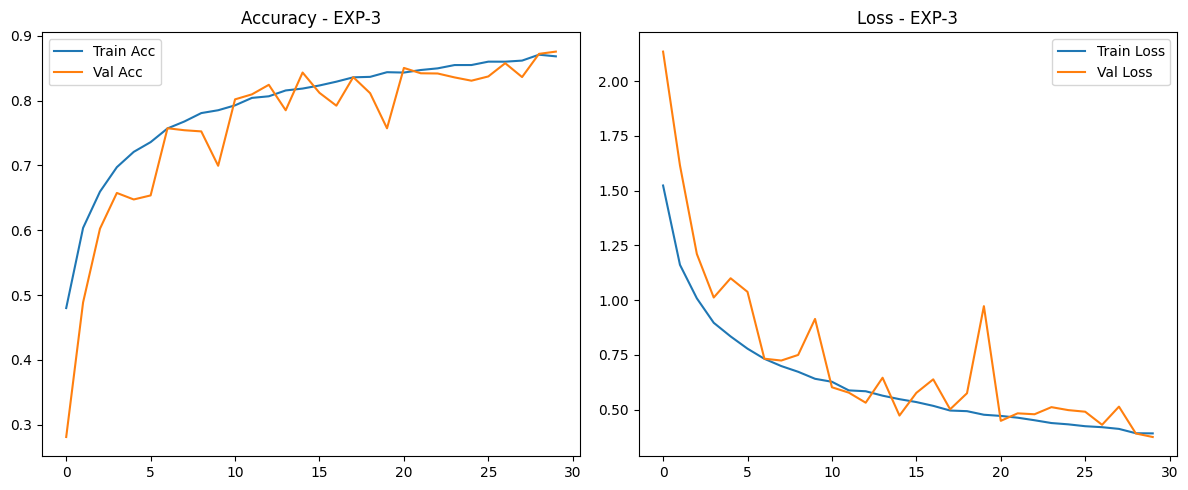

In [33]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history3.history['accuracy'], label='Train Acc')
plt.plot(history3.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy - EXP-3')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history3.history['loss'], label='Train Loss')
plt.plot(history3.history['val_loss'], label='Val Loss')
plt.title('Loss - EXP-3')
plt.legend()

plt.tight_layout()
plt.show()

#### 4th experiment (increase number of layers and neurons , increase the batch size  , same data augmentation)

In [39]:
img_size = (224, 224)
batch_size =64

base_dir  = "C:\\Users\\Waseem Al-mahainy\\Desktop\\UnI\\5th Year\\1st sem\\Jr\\Jr project\\Image classification what is this feature\\animals10_split"
train_dir = os.path.join(base_dir, "train")
test_dir  = os.path.join(base_dir, "test")

train_datagen4 = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest",
)

test_datagen4 = ImageDataGenerator(
    rescale=1./255
)

train_ds4 = train_datagen4.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True,
    seed=42,
)

test_ds4= test_datagen4.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False,
)

Found 25149 images belonging to 10 classes.
Found 9447 images belonging to 10 classes.


In [46]:
model4 = Sequential([
    
    Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Dropout(0.3),
    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])

In [47]:
from keras.optimizers import Adam
model4.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [48]:
history4 = model4.fit(
    train_ds4,
    epochs=30,
    validation_data=test_ds4,
    batch_size=64
)

Epoch 1/30
393/393 [==============================] - 181s 457ms/step - loss: 1.8320 - accuracy: 0.4207 - val_loss: 2.4317 - val_accuracy: 0.2394
Epoch 2/30
393/393 [==============================] - 181s 460ms/step - loss: 1.2074 - accuracy: 0.5859 - val_loss: 1.1506 - val_accuracy: 0.6078
Epoch 3/30
393/393 [==============================] - 176s 447ms/step - loss: 1.0270 - accuracy: 0.6506 - val_loss: 1.1923 - val_accuracy: 0.5925
Epoch 4/30
393/393 [==============================] - 177s 449ms/step - loss: 0.9148 - accuracy: 0.6870 - val_loss: 1.0014 - val_accuracy: 0.6600
Epoch 5/30
393/393 [==============================] - 176s 449ms/step - loss: 0.8286 - accuracy: 0.7168 - val_loss: 0.9664 - val_accuracy: 0.6726
Epoch 6/30
393/393 [==============================] - 174s 443ms/step - loss: 0.7784 - accuracy: 0.7372 - val_loss: 0.8088 - val_accuracy: 0.7257
Epoch 7/30
393/393 [==============================] - 175s 446ms/step - loss: 0.7246 - accuracy: 0.7554 - val_loss: 1.4898 -

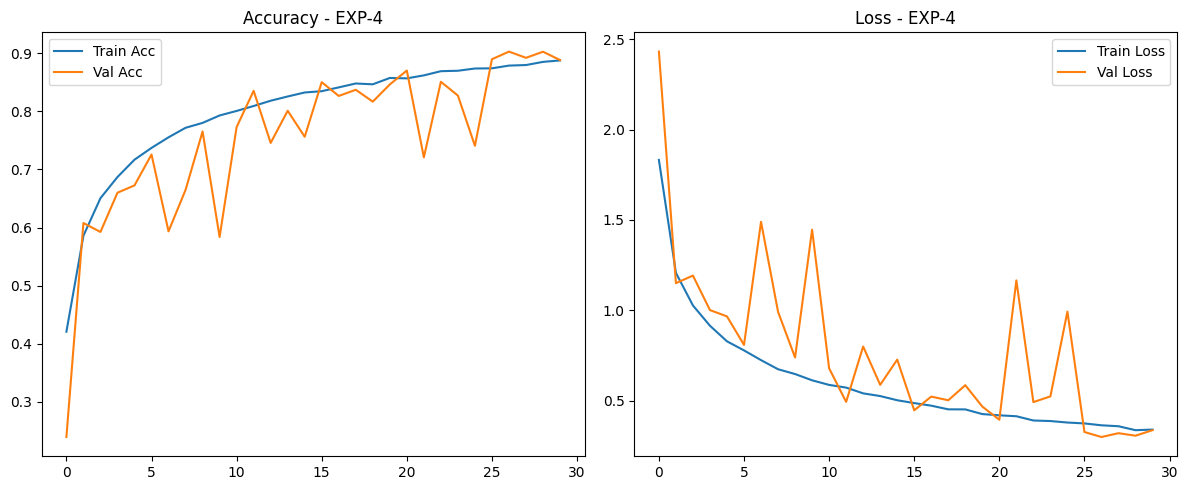

In [90]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history4.history['accuracy'], label='Train Acc')
plt.plot(history4.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy - EXP-4')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history4.history['loss'], label='Train Loss')
plt.plot(history4.history['val_loss'], label='Val Loss')
plt.title('Loss - EXP-4')
plt.legend()

plt.tight_layout()
plt.show()

#### 5th experiment (increase number of layers and neurons , decrease the learning rate  , increase the batch size , add regularization  , add a little dropout because the validation loss curve is jumping too much so we have a little overfitting in some epoches "val fluctuates more than train" )

In [50]:
img_size = (224, 224)
batch_size =64

base_dir  = "C:\\Users\\Waseem Al-mahainy\\Desktop\\UnI\\5th Year\\1st sem\\Jr\\Jr project\\Image classification what is this feature\\animals10_split"
train_dir = os.path.join(base_dir, "train")
test_dir  = os.path.join(base_dir, "test")

train_datagen5 = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest",
)

test_datagen5 = ImageDataGenerator(
    rescale=1./255
)

train_ds5 = train_datagen5.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True,
    seed=42,
)

test_ds5= test_datagen5.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False,
)

Found 25149 images belonging to 10 classes.
Found 9447 images belonging to 10 classes.


In [56]:
from keras.regularizers import l2, l1, l1_l2
model5 = Sequential([
    
    Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Dropout(0.3),
    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu',kernel_regularizer=l2(1e-4)),
    Dropout(0.3),

    Dense(10, activation='softmax')
])

In [57]:
model5.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [58]:
history5 = model5.fit(
    train_ds5,
    epochs=30,
    validation_data=test_ds5,
    batch_size=64
)

Epoch 1/30
393/393 [==============================] - 214s 543ms/step - loss: 1.9249 - accuracy: 0.3526 - val_loss: 1.9671 - val_accuracy: 0.3232
Epoch 2/30
393/393 [==============================] - 173s 439ms/step - loss: 1.5721 - accuracy: 0.4765 - val_loss: 1.4592 - val_accuracy: 0.5169
Epoch 3/30
393/393 [==============================] - 173s 440ms/step - loss: 1.4250 - accuracy: 0.5280 - val_loss: 1.2376 - val_accuracy: 0.6079
Epoch 4/30
393/393 [==============================] - 174s 443ms/step - loss: 1.3100 - accuracy: 0.5651 - val_loss: 1.1966 - val_accuracy: 0.6161
Epoch 5/30
393/393 [==============================] - 174s 443ms/step - loss: 1.2270 - accuracy: 0.5958 - val_loss: 1.1266 - val_accuracy: 0.6395
Epoch 6/30
393/393 [==============================] - 175s 444ms/step - loss: 1.1621 - accuracy: 0.6192 - val_loss: 1.1078 - val_accuracy: 0.6425
Epoch 7/30
393/393 [==============================] - 175s 446ms/step - loss: 1.1086 - accuracy: 0.6378 - val_loss: 1.0031 -

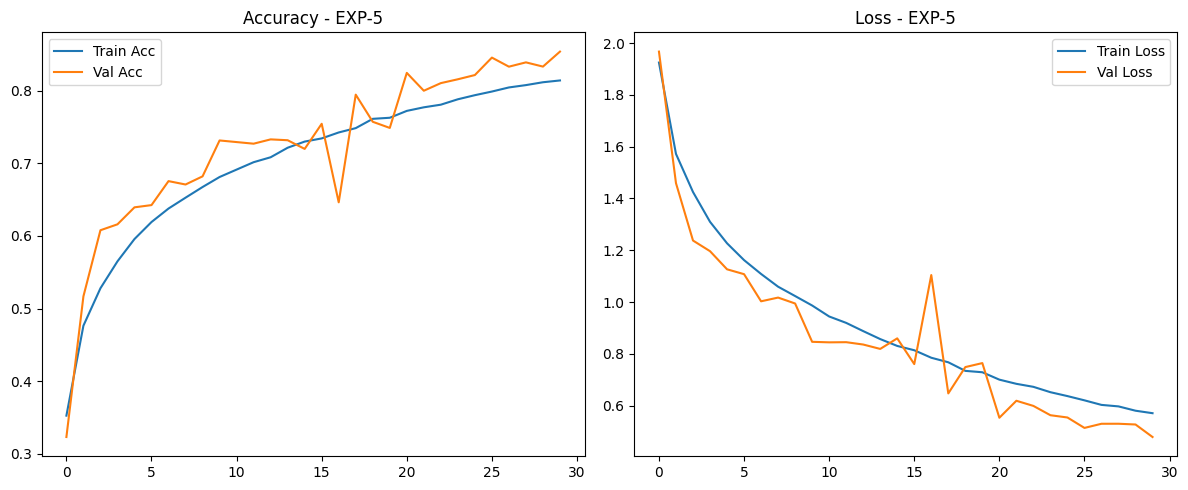

In [59]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history5.history['accuracy'], label='Train Acc')
plt.plot(history5.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy - EXP-5')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history5.history['loss'], label='Train Loss')
plt.plot(history5.history['val_loss'], label='Val Loss')
plt.title('Loss - EXP-5')
plt.legend()

plt.tight_layout()
plt.show()

#### 6th experiment (increase number of epochs , add checkpoint , add early stopping , add reduce learning rate dynamic )

In [61]:
img_size = (224, 224)
batch_size =64

base_dir  = "C:\\Users\\Waseem Al-mahainy\\Desktop\\UnI\\5th Year\\1st sem\\Jr\\Jr project\\Image classification what is this feature\\animals10_split"
train_dir = os.path.join(base_dir, "train")
test_dir  = os.path.join(base_dir, "test")

train_datagen6 = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest",
)

test_datagen6 = ImageDataGenerator(
    rescale=1./255
)

train_ds6 = train_datagen6.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True,
    seed=42,
)

test_ds6= test_datagen6.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False,
)

Found 25149 images belonging to 10 classes.
Found 9447 images belonging to 10 classes.


In [64]:
from keras.regularizers import l2, l1, l1_l2
model6 = Sequential([
    
    Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Dropout(0.3),
    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu',kernel_regularizer=l2(1e-4)),
    Dropout(0.3),

    Dense(10, activation='softmax')
])

In [63]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_cb6 = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_cb6 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint_cb6 = ModelCheckpoint(
    "exp5_best.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)


In [65]:
model6.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [67]:
history6 = model6.fit(
    train_ds6,
    epochs=50,
    validation_data=test_ds6,
    batch_size=64,
    callbacks=[early_cb6, reduce_lr_cb6, checkpoint_cb6]
)

Epoch 1/50
393/393 [==============================] - ETA: 0s - loss: 1.9151 - accuracy: 0.3492
Epoch 1: val_accuracy improved from -inf to 0.24992, saving model to exp5_best.keras
393/393 [==============================] - 186s 472ms/step - loss: 1.9151 - accuracy: 0.3492 - val_loss: 2.1451 - val_accuracy: 0.2499 - lr: 1.0000e-04
Epoch 2/50
393/393 [==============================] - ETA: 0s - loss: 1.5841 - accuracy: 0.4699
Epoch 2: val_accuracy improved from 0.24992 to 0.55690, saving model to exp5_best.keras
393/393 [==============================] - 176s 448ms/step - loss: 1.5841 - accuracy: 0.4699 - val_loss: 1.3654 - val_accuracy: 0.5569 - lr: 1.0000e-04
Epoch 3/50
393/393 [==============================] - ETA: 0s - loss: 1.4176 - accuracy: 0.5282
Epoch 3: val_accuracy improved from 0.55690 to 0.58442, saving model to exp5_best.keras
393/393 [==============================] - 174s 443ms/step - loss: 1.4176 - accuracy: 0.5282 - val_loss: 1.2606 - val_accuracy: 0.5844 - lr: 1.0000

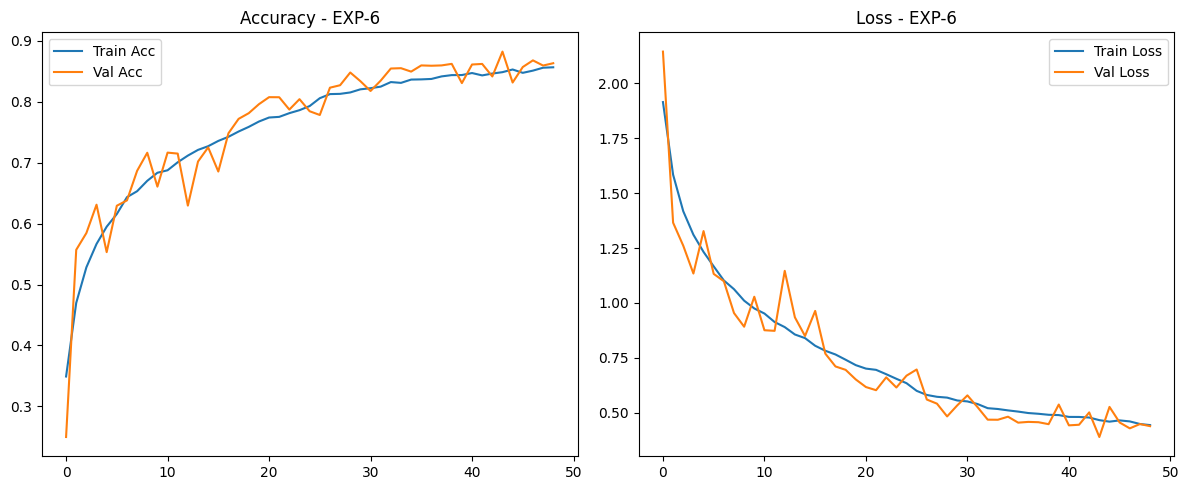

In [68]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history6.history['accuracy'], label='Train Acc')
plt.plot(history6.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy - EXP-6')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history6.history['loss'], label='Train Loss')
plt.plot(history6.history['val_loss'], label='Val Loss')
plt.title('Loss - EXP-6')
plt.legend()

plt.tight_layout()
plt.show()

#### 7th experiment (from exp-4 we edit on it to get a better curve , we add early stopping and reduce the learning rate dynamiclly , add check point , increse number of epochs ,  replace the regularizer )

In [69]:
img_size = (224, 224)
batch_size =64

base_dir  = "C:\\Users\\Waseem Al-mahainy\\Desktop\\UnI\\5th Year\\1st sem\\Jr\\Jr project\\Image classification what is this feature\\animals10_split"
train_dir = os.path.join(base_dir, "train")
test_dir  = os.path.join(base_dir, "test")

train_datagen7 = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest",
)

test_datagen7 = ImageDataGenerator(
    rescale=1./255
)

train_ds7 = train_datagen7.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True,
    seed=42,
)

test_ds7= test_datagen7.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False,
)

Found 25149 images belonging to 10 classes.
Found 9447 images belonging to 10 classes.


In [70]:
model7 = Sequential([
    
    Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.3),
    
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(10, activation='softmax')
])

In [71]:

early_cb7 = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_cb7 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint_cb7 = ModelCheckpoint(
    "exp7_best.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)


In [76]:
model7.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [77]:
history7 = model7.fit(
    train_ds7,
    epochs=50,    
    validation_data=test_ds7,
    callbacks=[early_cb7, reduce_lr_cb7, checkpoint_cb7]
)

Epoch 1/50
393/393 [==============================] - ETA: 0s - loss: 1.9440 - accuracy: 0.3291
Epoch 1: val_accuracy improved from -inf to 0.32984, saving model to exp7_best.keras
393/393 [==============================] - 286s 725ms/step - loss: 1.9440 - accuracy: 0.3291 - val_loss: 2.0250 - val_accuracy: 0.3298 - lr: 1.0000e-04
Epoch 2/50
393/393 [==============================] - ETA: 0s - loss: 1.5529 - accuracy: 0.4679
Epoch 2: val_accuracy improved from 0.32984 to 0.55859, saving model to exp7_best.keras
393/393 [==============================] - 181s 460ms/step - loss: 1.5529 - accuracy: 0.4679 - val_loss: 1.3217 - val_accuracy: 0.5586 - lr: 1.0000e-04
Epoch 3/50
393/393 [==============================] - ETA: 0s - loss: 1.3899 - accuracy: 0.5234
Epoch 3: val_accuracy did not improve from 0.55859
393/393 [==============================] - 179s 456ms/step - loss: 1.3899 - accuracy: 0.5234 - val_loss: 1.3690 - val_accuracy: 0.5404 - lr: 1.0000e-04
Epoch 4/50
393/393 [============

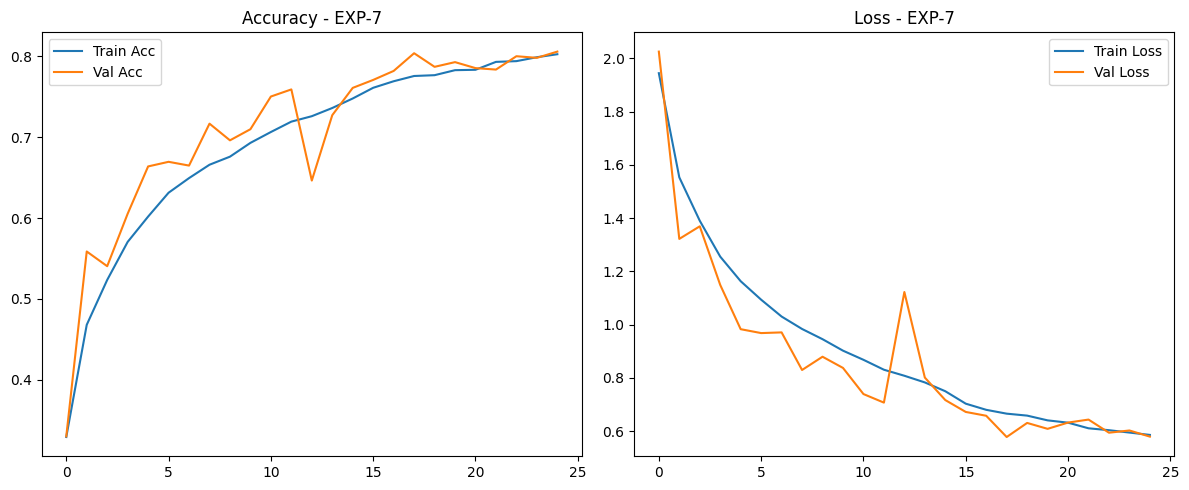

In [88]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history7.history['accuracy'], label='Train Acc')
plt.plot(history7.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy - EXP-7')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history7.history['loss'], label='Train Loss')
plt.plot(history7.history['val_loss'], label='Val Loss')
plt.title('Loss - EXP-7')
plt.legend()

plt.tight_layout()
plt.show()

#### 8th experiment (from exp-4 we edit on it to get a better curve ,we only increase the batch size , remove the dropout   )

In [2]:
img_size = (224, 224)
batch_size =64

base_dir  = "C:\\Users\\Waseem Al-mahainy\\Desktop\\UnI\\5th Year\\1st sem\\Jr\\Jr project\\Image classification what is this feature\\animals10_split"
train_dir = os.path.join(base_dir, "train")
test_dir  = os.path.join(base_dir, "test")

train_datagen8 = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest",
)

test_datagen8 = ImageDataGenerator(
    rescale=1./255
)

train_ds8 = train_datagen8.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=True,
    seed=42,
)

test_ds8= test_datagen8.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="sparse",
    shuffle=False,
)

Found 25149 images belonging to 10 classes.
Found 9447 images belonging to 10 classes.


In [3]:
model8 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Dropout(0.3),
    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])
model8.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 222, 222, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 111, 111, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 32)      9248      
                                                                 
 batch_normalization_1 (Batc  (None, 109, 109, 32)     128       
 hNormalization)                                                 
                                                        

In [4]:
early_cb8 = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_cb8 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint_cb8 = ModelCheckpoint(
    "exp8_best.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)


In [7]:
model8.compile(
    optimizer=Adam(learning_rate=1e-4),  
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [8]:
history8 = model8.fit(
    train_ds8,
    epochs=50,
    validation_data=test_ds8,
    callbacks=[early_cb8, reduce_lr_cb8, checkpoint_cb8]
)


Epoch 1/50
393/393 [==============================] - ETA: 0s - loss: 1.7050 - accuracy: 0.4128
Epoch 1: val_accuracy improved from -inf to 0.34000, saving model to exp8_best.keras
393/393 [==============================] - 321s 783ms/step - loss: 1.7050 - accuracy: 0.4128 - val_loss: 1.8818 - val_accuracy: 0.3400 - lr: 1.0000e-04
Epoch 2/50
393/393 [==============================] - ETA: 0s - loss: 1.3286 - accuracy: 0.5434
Epoch 2: val_accuracy improved from 0.34000 to 0.57637, saving model to exp8_best.keras
393/393 [==============================] - 212s 538ms/step - loss: 1.3286 - accuracy: 0.5434 - val_loss: 1.2406 - val_accuracy: 0.5764 - lr: 1.0000e-04
Epoch 3/50
393/393 [==============================] - ETA: 0s - loss: 1.1789 - accuracy: 0.5941
Epoch 3: val_accuracy did not improve from 0.57637
393/393 [==============================] - 217s 551ms/step - loss: 1.1789 - accuracy: 0.5941 - val_loss: 1.3391 - val_accuracy: 0.5276 - lr: 1.0000e-04
Epoch 4/50
393/393 [============

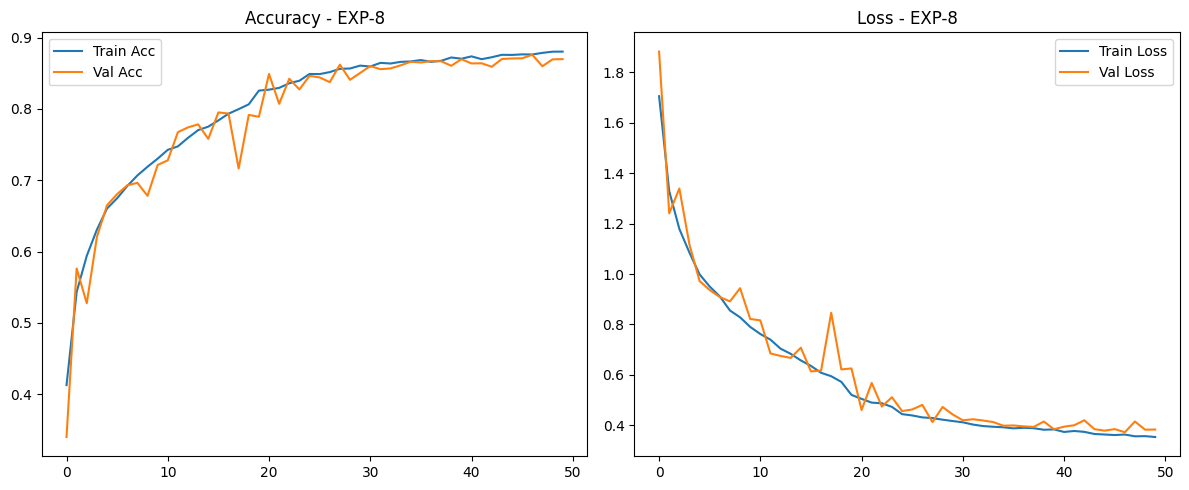

In [10]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history8.history['accuracy'], label='Train Acc')
plt.plot(history8.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy - EXP-8')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history8.history['loss'], label='Train Loss')
plt.plot(history8.history['val_loss'], label='Val Loss')
plt.title('Loss - EXP-8')
plt.legend()

plt.tight_layout()
plt.show()

#### saving models

In [9]:
# from tensorflow.keras.models import load_model
# save_dir = r"C:\Users\Waseem Al-mahainy\Desktop\UnI\5th Year\1st sem\Jr\Jr project\saved_models"
# history8 = load_model(os.path.join(save_dir, "animals10_exp8.h5"))

In [98]:
save_dir = r"C:\Users\Waseem Al-mahainy\Desktop\UnI\5th Year\1st sem\Jr\Jr project\saved_models"
os.makedirs(save_dir, exist_ok=True)
print("Saving models to:", save_dir)

Saving models to: C:\Users\Waseem Al-mahainy\Desktop\UnI\5th Year\1st sem\Jr\Jr project\saved_models


In [99]:
model1.save(os.path.join(save_dir, "animals10_exp1.h5"))
model2.save(os.path.join(save_dir, "animals10_exp2.h5"))
model3.save(os.path.join(save_dir, "animals10_exp3.h5"))
model4.save(os.path.join(save_dir, "animals10_exp4.h5"))
model5.save(os.path.join(save_dir, "animals10_exp5.h5"))
model6.save(os.path.join(save_dir, "animals10_exp6.h5"))
model7.save(os.path.join(save_dir, "animals10_exp7.h5"))
model8.save(os.path.join(save_dir, "animals10_exp8.h5"))

# to load a model we use this : model4_loaded = load_model(os.path.join(save_dir, "animals10_exp4.h5"))

#### evaluation

148/148 [==============================] - 39s 260ms/step


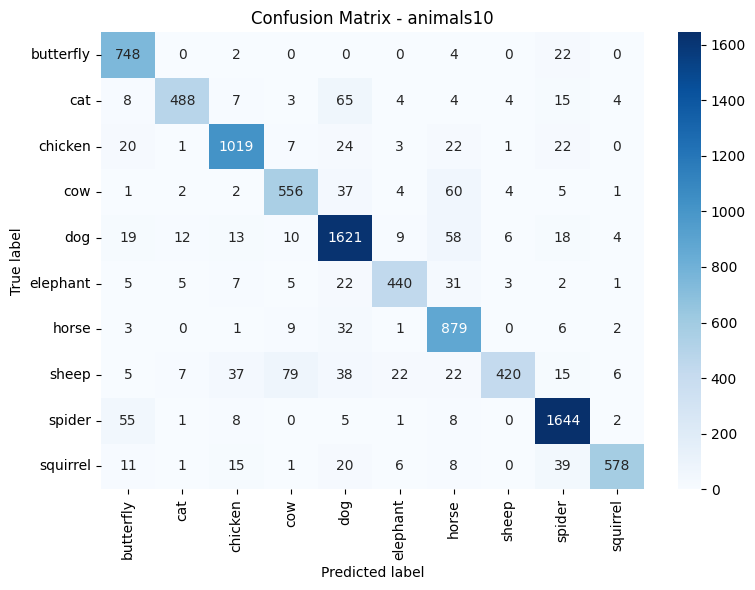

butterfly   : 96.39%
cat         : 81.06%
chicken     : 91.06%
cow         : 82.74%
dog         : 91.58%
elephant    : 84.45%
horse       : 94.21%
sheep       : 64.52%
spider      : 95.36%
squirrel    : 85.13%

Classification report:

              precision    recall  f1-score   support

   butterfly       0.85      0.96      0.91       776
         cat       0.94      0.81      0.87       602
     chicken       0.92      0.91      0.91      1119
         cow       0.83      0.83      0.83       672
         dog       0.87      0.92      0.89      1770
    elephant       0.90      0.84      0.87       521
       horse       0.80      0.94      0.87       933
       sheep       0.96      0.65      0.77       651
      spider       0.92      0.95      0.94      1724
    squirrel       0.97      0.85      0.91       679

    accuracy                           0.89      9447
   macro avg       0.90      0.87      0.88      9447
weighted avg       0.89      0.89      0.89      9447



In [100]:
from sklearn.metrics import confusion_matrix, classification_report


# ----- choose which experiment to evaluate -----
model_to_eval = model4         
test_ds_eval  = test_ds4        
class_names   = list(test_ds_eval.class_indices.keys())
num_classes   = len(class_names)

# ----- get predictions -----
test_ds_eval.reset() 
y_prob = model_to_eval.predict(test_ds_eval, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

# true labels from generator
y_true = test_ds_eval.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - animals10")
plt.tight_layout()
plt.show()

# Per-class accuracy
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

for class_name, acc in zip(class_names, per_class_accuracy):
    print(f"{class_name:12s}: {acc*100:.2f}%")

# Classification report (precision, recall, f1)
print("\nClassification report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))
